# Hierarchical Classification and Binary Severity Breakdowns

This notebook follows the supervisor recommendation to break the prediction task into binary classes and to test a hierarchical classification strategy. It compares several binary targets and then evaluates a two-stage pipeline in which migraine occurrence is predicted first and severity is predicted only for positive cases.

## 1. Import required libraries

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

warnings.filterwarnings('ignore')
plt.style.use('ggplot')


## 2. Load the dataset

In [2]:
data_path = Path('/Users/cioran/Documents/migraine-prediction-project/data/migraine_dataset.csv')
print('Loading dataset from:', data_path)
df = pd.read_csv(data_path)
df.head()


Loading dataset from: /Users/cioran/Documents/migraine-prediction-project/data/migraine_dataset.csv


,user_id,date,sleep_hours,mood_level,stress_level,hydration_level,screen_time,migraine_occurrence,migraine_severity
0,1,1/15/2024,7.8,3,2,2,4.7,1,1
1,1,1/16/2024,6.6,4,1,2,3.2,1,1
2,1,1/17/2024,8.5,4,2,2,4.7,1,2
3,1,1/18/2024,7.5,3,2,3,3.8,1,3
4,1,1/19/2024,9.0,3,2,1,6.8,1,2


## 3. Create the improved feature set

In [3]:
df['date'] = pd.to_datetime(df['date'])
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['sleep_stress_interaction'] = df['sleep_hours'] * df['stress_level']
df['screen_stress_interaction'] = df['screen_time'] * df['stress_level']
df['hydration_stress_interaction'] = df['hydration_level'] * df['stress_level']

features = [
    'sleep_hours',
    'mood_level',
    'stress_level',
    'hydration_level',
    'screen_time',
    'day_of_week',
    'month',
    'sleep_stress_interaction',
    'screen_stress_interaction',
    'hydration_stress_interaction',
]

X = df[features]
print('Feature matrix shape:', X.shape)
print('Severity distribution:')
print(df['migraine_severity'].value_counts().sort_index())


Feature matrix shape: (11879, 10)
Severity distribution:
migraine_severity
0    6119
1    2493
2    2874
3     393
Name: count, dtype: int64


## 4. Define the binary breakdowns

Three binary views are tested: migraine occurrence, moderate-or-severe migraine (`severity >= 2`), and severe migraine only (`severity == 3`).

In [4]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=3000))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced_subsample'
    ),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('model', CalibratedClassifierCV(SVC(random_state=42), method='sigmoid', cv=3))
    ]),
}

binary_targets = {
    'Migraine Occurrence': df['migraine_occurrence'],
    'Moderate/Severe Migraine (>=2)': (df['migraine_severity'] >= 2).astype(int),
    'Severe Migraine Only (=3)': (df['migraine_severity'] == 3).astype(int),
}


## 5. Train and evaluate the binary models

Each binary target is evaluated using the same four models so that the difficulty of different classification boundaries can be compared.

In [5]:

binary_results = []

for target_name, target in binary_targets.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X, target, test_size=0.2, random_state=42, stratify=target
    )

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)
        proba = model.predict_proba(X_test)[:, 1]

        accuracy = accuracy_score(y_test, predictions)
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_test, predictions, average='binary', zero_division=0
        )
        roc_auc = roc_auc_score(y_test, proba)

        binary_results.append({
            'Target': target_name,
            'Model': model_name,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1': f1,
            'ROC-AUC': roc_auc,
        })

binary_comparison_df = pd.DataFrame(binary_results)
binary_comparison_df.sort_values(by=['Target', 'ROC-AUC', 'F1'], ascending=[True, False, False]).reset_index(drop=True)


,Target,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Migraine Occurrence,Gradient Boosting,0.610269,0.603860,0.570312,0.586607,0.641245
1,Migraine Occurrence,SVM,0.610690,0.600354,0.589410,0.594831,0.629493
2,Migraine Occurrence,Logistic Regression,0.592593,0.583183,0.559896,0.571302,0.628764
3,Migraine Occurrence,Random Forest,0.566498,0.555556,0.529514,0.542222,0.602686
4,Moderate/Severe Migraine (>=2),Gradient Boosting,0.737795,0.596154,0.142420,0.229913,0.738547
5,Moderate/Severe Migraine (>=2),Logistic Regression,0.729798,0.522267,0.197550,0.286667,0.729930
6,Moderate/Severe Migraine (>=2),SVM,0.741582,0.648855,0.130168,0.216837,0.703623
7,Moderate/Severe Migraine (>=2),Random Forest,0.726010,0.502604,0.295559,0.372228,0.692249
8,Severe Migraine Only (=3),Gradient Boosting,0.966330,0.400000,0.025316,0.047619,0.821559
9,Severe Migraine Only (=3),Logistic Regression,0.966751,0.000000,0.000000,0.000000,0.815500


## 6. Review binary breakdown performance

This table shows whether the simpler binary tasks are easier than the multi-class severity task.

In [6]:
binary_comparison_df.sort_values(by=['Target', 'ROC-AUC', 'F1'], ascending=[True, False, False]).reset_index(drop=True)

,Target,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Migraine Occurrence,Gradient Boosting,0.610269,0.603860,0.570312,0.586607,0.641245
1,Migraine Occurrence,SVM,0.610690,0.600354,0.589410,0.594831,0.629493
2,Migraine Occurrence,Logistic Regression,0.592593,0.583183,0.559896,0.571302,0.628764
3,Migraine Occurrence,Random Forest,0.566498,0.555556,0.529514,0.542222,0.602686
4,Moderate/Severe Migraine (>=2),Gradient Boosting,0.737795,0.596154,0.142420,0.229913,0.738547
5,Moderate/Severe Migraine (>=2),Logistic Regression,0.729798,0.522267,0.197550,0.286667,0.729930
6,Moderate/Severe Migraine (>=2),SVM,0.741582,0.648855,0.130168,0.216837,0.703623
7,Moderate/Severe Migraine (>=2),Random Forest,0.726010,0.502604,0.295559,0.372228,0.692249
8,Severe Migraine Only (=3),Gradient Boosting,0.966330,0.400000,0.025316,0.047619,0.821559
9,Severe Migraine Only (=3),Logistic Regression,0.966751,0.000000,0.000000,0.000000,0.815500


## 7. Build a hierarchical classifier

The hierarchical approach uses two stages:
1. Predict whether migraine occurs.
2. If migraine is predicted, assign a severity level among the positive cases.

In [7]:

train_index, test_index = train_test_split(
    df.index, test_size=0.2, random_state=42, stratify=df['migraine_occurrence']
)
train_df = df.loc[train_index].copy()
test_df = df.loc[test_index].copy()

stage_one_model = GradientBoostingClassifier(random_state=42)
stage_one_model.fit(train_df[features], train_df['migraine_occurrence'])

positive_train_df = train_df[train_df['migraine_occurrence'] == 1].copy()
stage_two_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', CalibratedClassifierCV(SVC(random_state=42), method='sigmoid', cv=3))
])
stage_two_model.fit(positive_train_df[features], positive_train_df['migraine_severity'])

occurrence_predictions = stage_one_model.predict(test_df[features])
severity_predictions = np.zeros(len(test_df), dtype=int)
positive_mask = occurrence_predictions == 1

if positive_mask.any():
    severity_predictions[positive_mask] = stage_two_model.predict(
        test_df.loc[positive_mask, features]
    )

true_severity = test_df['migraine_severity'].to_numpy()

hierarchical_accuracy = accuracy_score(true_severity, severity_predictions)
hierarchical_precision, hierarchical_recall, hierarchical_f1, _ = precision_recall_fscore_support(
    true_severity, severity_predictions, average='macro', zero_division=0
)
hierarchical_confusion = confusion_matrix(true_severity, severity_predictions)

print('Hierarchical severity accuracy:', hierarchical_accuracy)
print('Hierarchical macro precision:', hierarchical_precision)
print('Hierarchical macro recall:', hierarchical_recall)
print('Hierarchical macro F1:', hierarchical_f1)
print('\nHierarchical confusion matrix:\n')
print(hierarchical_confusion)
print('\nHierarchical classification report:\n')
print(classification_report(true_severity, severity_predictions, zero_division=0))


Hierarchical severity accuracy: 0.5088383838383839
Hierarchical macro precision: 0.31802656603591895
Hierarchical macro recall: 0.3408665960978151
Hierarchical macro F1: 0.29537531539156336

Hierarchical confusion matrix:

[[793  22 409   0]
 [321  15 162   0]
 [167  17 401   0]
 [  7   2  60   0]]

Hierarchical classification report:

              precision    recall  f1-score   support

           0       0.62      0.65      0.63      1224
           1       0.27      0.03      0.05       498
           2       0.39      0.69      0.50       585
           3       0.00      0.00      0.00        69

    accuracy                           0.51      2376
   macro avg       0.32      0.34      0.30      2376
weighted avg       0.47      0.51      0.46      2376



## 8. Visualise the hierarchical confusion matrix

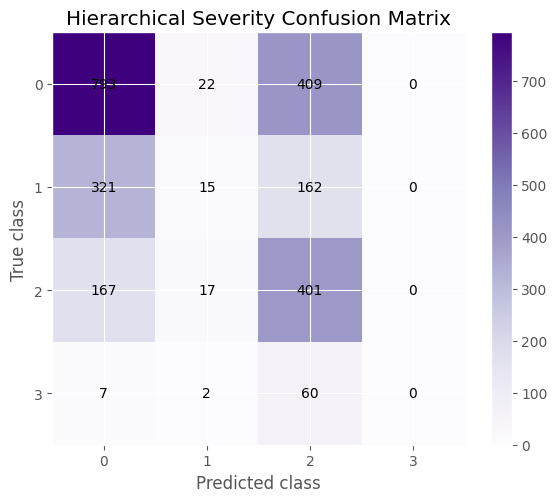

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(hierarchical_confusion, cmap='Purples')
ax.set_title('Hierarchical Severity Confusion Matrix')
ax.set_xlabel('Predicted class')
ax.set_ylabel('True class')
ax.set_xticks(range(4))
ax.set_yticks(range(4))
for i in range(hierarchical_confusion.shape[0]):
    for j in range(hierarchical_confusion.shape[1]):
        ax.text(j, i, hierarchical_confusion[i, j], ha='center', va='center', color='black')
fig.colorbar(image, ax=ax)
plt.tight_layout()
plt.show()

## 9. Conclusion

The binary breakdowns help show which distinctions are easier for the models, while the hierarchical experiment provides a structured way to model occurrence first and severity second. This notebook therefore addresses the supervisor recommendation to study both binary and hierarchical classification.